# Pre-processing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, randint
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
#%pip install xgboost
from sympy import fft
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import RandomizedSearchCV,cross_val_predict
import matplotlib.patches as mpatches


In [3]:
df = pd.read_csv("inside.csv")
df2 = pd.read_csv("inside2.csv")
df3 = pd.read_csv("outside.csv")
df4 = pd.read_csv("outside2.csv")
df5 = pd.read_csv("rady.csv")
df6 = pd.read_csv("chipeta.csv")
df7 = pd.read_csv("chipeta_walk.csv")

dfA = pd.concat([df,df2], axis=0,  ignore_index=True)
dfB = pd.concat([dfA, df3], axis =0,  ignore_index=True)
dfD = pd.concat([dfB, df5], axis =0,  ignore_index=True)
dfE = pd.concat([dfD, df6], axis =0,  ignore_index=True)
dfF = pd.concat([dfE, df7], axis =0,  ignore_index=True)

dfC = pd.concat([dfF, df4], axis =0,  ignore_index=True)
#print(dfC)


In [ ]:
#Pre-process/condense data
bikeLabled = dfC
label = bikeLabled["Class"]
outputLabels = []
#print(label)
bike1 = bikeLabled.drop(columns = "Class") #unlabled
columns=['MagX1', 'MagY1', 'MagZ1', 'AccX1', 'AccY1', 'AccZ1', 'MagX2', 'MagY2', 'MagZ2', 'AccX2', 'AccY2', 'AccZ2', 'MagX3', 'MagY3', 'MagZ3', 'AccX3', 'AccY3', 'AccZ3']
WINDOW_SIZE = 50 #pretty sure this is 49 now, not 50...
dataClassified = list()
dataClass2 = list()
for j in range(0, int(len(bike1)/WINDOW_SIZE)):
    startIndex = j*50 #50 or 49??
    endIndex = startIndex + 49
    outputLabels.append(label[endIndex])
    mean = bike1[startIndex:endIndex].mean().to_numpy()
    stdVal = bike1[startIndex:endIndex].std().to_numpy()
    upperQ = bike1[startIndex:endIndex].quantile(0.75).to_numpy()
    lowerQ = bike1[startIndex:endIndex].quantile(0.25).to_numpy()
    mySeq = bike1[startIndex:endIndex].std().to_numpy()
    shape = fft(mySeq,4)
    print("FFT: ",shape,"\n")
    
    row = list()
    row2 = list()
    for index in range(len(mean)):
        row2.append(mean[index])
        row2.append(lowerQ[index])
        row2.append(upperQ[index])
        row2.append(stdVal[index])
        row2.append(shape[index])

    dataClass2.append(row2)

testOutput = pd.DataFrame(dataClass2)
testOutput["Class"] = outputLabels
#print("Condensed data point (Fourier): ")
#print(testOutput)

testOutput.to_csv('FourierTest.csv', index = False, header=False, mode ="w")
print("complete")

FFT:  [1008.74505845838, -272.05392104028 + 511.870895653037*I, 121.858655522484 + 104.942029955365*I, -289.377580912677 + 105.853497914168*I, -132.84380829686 + 181.000554919603*I, -406.575853159303 - 521.367682436407*I, 513.449751297523 - 97.3258429948247*I, -26.9591519615613 + 83.2009241545737*I, 81.334912516619 + 46.150460632311*I, 110.234985558859 + 118.09911145042*I, -361.764140131296 + 150.899150003293*I, 107.892784198485 - 360.427538885146*I, 39.0395835489161 + 80.6112897704368*I, 175.1940788959 + 15.6018805924252*I, -109.228006955285 - 3.9128547200089*I, 280.899070563106 + 284.261687962738*I, -632.542864385967, 280.898859692646 - 284.26181642645*I, -109.228010200894 + 3.91288988620354*I, 175.194066810999 - 15.6018510404186*I, 39.0395564936453 - 80.611302352655*I, 107.892889430514 + 360.427448403669*I, -361.764126085958 - 150.899008129739*I, 110.234870650378 - 118.099251220116*I, 81.3349055480938 - 46.150460632311*I, -26.9593116044703 - 83.200823227677*I, 513.449792326793 + 97.

FFT:  [891.348447328573, -283.225479649138 + 405.141536666932*I, 162.746718088318 + 133.538011022568*I, -351.355149391849 + 38.5903709446172*I, -22.4792618476629 + 118.621334982636*I, -327.881672020345 - 451.536556964081*I, 480.815720847548 - 17.5026292855477*I, -21.3145893911169 + 79.1624390807546*I, 22.1264475539907 + 155.939590780003*I, -10.8623500488483 + 25.0577483081249*I, -327.426031351561 + 81.5862354950462*I, 128.40398974899 - 398.298630768919*I, 85.532933018644 + 30.0923226407873*I, 315.257455680967 + 48.3645457578592*I, -138.173135247883 + 159.124642282215*I, 183.775173533491 + 274.75805572257*I, -640.152326315850, 183.775008626658 - 274.758143882597*I, -138.173187418501 - 159.124592035398*I, 315.25745399946 - 48.3645359052423*I, 85.5329191910803 - 30.0923306164802*I, 128.40407668043 + 398.298540884878*I, -327.426002548475 - 81.5861019136491*I, -10.8624416013564 - 25.0578397330204*I, 22.1264240077693 - 155.939590780003*I, -21.3147224674861 - 79.1623679335758*I, 480.815754869

FFT:  [1129.17742118362, -342.415078241384 + 549.443572629733*I, 134.744041125783 + 125.362149413296*I, -336.702829292621 + 10.5494765969594*I, -24.6356222660092 + 257.556974551708*I, -498.141418915281 - 552.904957387508*I, 572.043472614723 - 88.1390147144961*I, 9.36311120143379 + 73.513907174934*I, 20.8219963981384 + 202.78704889394*I, 5.32507331891475 - 40.8438511752142*I, -288.574530994649 + 161.53257022743*I, 96.8740971123387 - 404.373287644999*I, 60.9504313384647 + 53.1478477624075*I, 311.696556365044 + 8.5666596072188*I, -135.756704950804 + 161.011542042898*I, 204.126703540854 + 274.215254938919*I, -657.826651591187, 204.126524210329 - 274.215345149178*I, -135.756752639729 - 161.011493420671*I, 311.696543858067 - 8.56664750481848*I, 60.9504151089458 - 53.147853233926*I, 96.8741914307391 + 404.373198030595*I, -288.574509423009 - 161.532435542797*I, 5.32500899969098 + 40.8437396987238*I, 20.8219657781481 - 202.78704889394*I, 9.36295555226744 - 73.5138443780744*I, 572.043510411623 +

FFT:  [1109.49170881832, -372.824844659554 + 583.428002160099*I, 79.4035887249816 - 24.9626022308675*I, -159.651827915875 + 39.2828653270052*I, -52.7983463441662 + 319.038677294094*I, -506.609717459844 - 493.129729745316*I, 549.657047702349 - 98.5998994827106*I, -90.3149338908679 + 151.315709274191*I, -16.6229992620179 + 7.5272635720255*I, 98.1412219455773 - 7.64506935246233*I, -270.89544598467 + 121.993753968736*I, 134.56869905732 - 366.584868459732*I, 114.189987940231 + 97.2897683602548*I, 197.913429615594 + 76.7619332620673*I, -114.303558051844 + 69.5178606452095*I, 209.57047574793 + 318.7404245907*I, -677.983928161668, 209.570259073661 - 318.74053891634*I, -114.303558590743 - 69.5178235145638*I, 197.913399564582 - 76.7619206702086*I, 114.189958077246 - 97.2897798709512*I, 134.568794864364 + 366.584771544287*I, -270.895422730519 - 121.993628726767*I, 98.141142519545 + 7.64491038471044*I, -16.623000398603 - 7.5272635720255*I, -90.3151122931338 - 151.315597740937*I, 549.657080590614 +

FFT:  [1217.45534870751, -426.537287469025 + 595.841096783381*I, 145.208299180537 + 34.0319099790617*I, -263.433239087038 + 18.8210119553342*I, -12.050605723065 + 341.049080388152*I, -580.727038106384 - 545.421760343406*I, 576.72234739541 - 127.418938946305*I, -19.4844850608838 + 87.2145917421391*I, 3.47759134416222 + 98.876618444704*I, 144.087079291056 - 42.8340024811848*I, -279.341396253315 + 245.173859937835*I, 93.1785241361375 - 326.538073084059*I, -46.9325673073718 + 62.3593734139869*I, 292.334348858281 + 3.17178903890503*I, -241.915306982768 + 59.4807067085439*I, 334.223417039246 + 186.739708363433*I, -616.056858875128, 334.223238347586 - 186.739856539954*I, -241.915302586739 - 59.4806292010844*I, 292.334314910858 - 3.17178655773743*I, -46.9325757106061 - 62.3593688529171*I, 93.17859541507 + 326.53799151179*I, -279.341385731112 - 245.173730447534*I, 144.087012366158 + 42.8338470583555*I, 3.47757641420927 - 98.876618444704*I, -19.4846770412017 - 87.2145077807069*I, 576.72238444211

...

FFT:  [64.1245901928147, -13.9799464298708 + 34.0621475291925*I, 7.9614076092752 + 2.7415684061918*I, -12.1891740944347 + 8.26046532086483*I, 3.08702704789366 + 13.419521074942*I, -33.3180507862435 - 9.44316295185873*I, 19.1477440430741 - 18.186202678298*I, -1.79534666004242 + 5.12633921901627*I, 6.25051176045108 - 3.13402956995132*I, 0.0679888833724922 + 0.262696766282976*I, 4.89391225908939 + 0.525913473202493*I, 1.28730317689854 + 1.48776055350922*I, 2.16543301633775 + 0.8732042856017*I, 3.38207623821489 + 4.03891277813903*I, -1.47137461695357 + 1.87997139266248*I, 2.55088597315156 + 9.25905054740453*I, -16.4932022109776, 2.55087756787936 - 9.25905432944305*I, -1.47137414242132 - 1.8799680573842*I, 3.3820743098751 - 4.03891474873727*I, 2.16543289526094 - 0.873204149112333*I, 1.28730152573565 - 1.48776508162115*I, 4.89391533395655 - 0.525911172609314*I, 0.0679874978856134 - 0.262703103110588*I, 6.25051223367635 + 3.13402956995132*I, -1.79535454623293 - 5.12633647033281*I, 19.14774861

FFT:  [390.602259665666, -215.600515303441 + 209.767627438551*I, 23.5785870772875 - 144.152630986476*I, 61.7067027755586 + 17.4042121449326*I, -20.5005979128649 + 165.085171180737*I, -178.799507443113 - 178.541657825121*I, 230.569491611486 - 0.295881278425334*I, -118.175050612319 + 112.292047826344*I, -26.5182633498707 - 126.585424996662*I, 142.50795406975 + 33.7800656528328*I, -134.095313520354 + 86.6026923126142*I, 50.5149979772984 - 130.819830304964*I, 31.8817575116651 + 67.7856714987628*I, -9.4641778924694 + 40.8196825792748*I, -65.1902564366944 - 91.5127222028819*I, 163.67486054091 + 99.1846084069147*I, -235.073718595301, 163.674763335644 - 99.1847032021428*I, -65.1902029739209 + 91.5127365488631*I, -9.46420248674074 - 40.8196718868397*I, 31.8817420670397 - 67.7856746597508*I, 50.5150426456244 + 130.819801403836*I, -134.095320118784 - 86.6026400219085*I, 142.507901507863 - 33.7801669487648*I, -26.5182442360046 + 126.585424996662*I, -118.17514734011 - 112.291966412303*I, 230.569487

FFT:  [191.839248539725, -61.1664671846993 + 101.296760176037*I, 14.0380813290769 - 2.33461036364966*I, -30.942982886133 + 6.4110971874089*I, -1.05328816986423 + 48.5057819062463*I, -86.7877804133686 - 70.9505076463493*I, 86.9442984266375 - 26.8253090891488*I, -4.71808928333908 + 26.8600372797234*I, -2.73666238916933 + 7.8478171614686*I, 9.74643610475611 - 0.84783139031466*I, -37.9351150264203 + 14.7488465923946*I, 21.1488574915551 - 47.8942692631893*I, 9.05470903323022 + 9.58769298339363*I, 37.6299853002906 + 9.32847032061168*I, -20.6019813496508 + 12.2133014735791*I, 35.4071372644388 + 46.4910192547155*I, -103.560222128618, 35.4071044036743 - 46.4910386339168*I, -20.601981242593 - 12.2132936245171*I, 37.6299804988218 - 9.32847091481501*I, 9.05470652245263 - 9.58769353549111*I, 21.1488676607592 + 47.894253469111*I, -37.9351089165941 - 14.7488273159592*I, 9.74642360152552 + 0.847808085040336*I, -2.73666357415667 - 7.8478171614686*I, -4.71812064890845 - 26.8600229426228*I, 86.9443066207

FFT:  [351.864682344306, -90.1268389578631 + 176.378742862894*I, 69.0120995248327 + 32.0510786262856*I, -118.325111792623 + 79.2544875744366*I, -28.0502582034277 + 21.8290645244374*I, -148.869580701124 - 97.3361462651722*I, 140.561284030674 - 87.3248083210559*I, -15.6971444973762 + 69.6521181337644*I, 8.23772589423131 - 51.3073837802347*I, 40.0183177171091 + 64.5474080469608*I, -104.695092999144 - 29.7256284956423*I, 82.2470555732257 - 61.9291809104494*I, 6.88834900285411 - 9.42779328801826*I, 110.140607626121 + 64.1703501428056*I, -77.9042167207245 + 20.4402739894225*I, 88.8764700974796 + 113.587983573645*I, -257.678314498589, 88.876391235188 - 113.588036221062*I, -77.9042172750398 - 20.4402396510233*I, 110.140598604435 - 64.1703626078457*I, 6.88834758042345 + 9.42779055110987*I, 82.2470574526743 + 61.9291335495855*I, -104.695061821083 + 29.7256734269563*I, 40.0182623022575 - 64.5474614286351*I, 8.23773364143017 + 51.3073837802347*I, -15.6972152902816 - 69.652075017242*I, 140.56132053

FFT:  [1646.03501908018, -70.9052556422931 + 920.913771003871*I, 164.452692406902 + 399.32455547822*I, -430.460843588526 + 408.246961012141*I, -374.519077050554 + 420.796755146913*I, -937.690297921971 - 572.67220608154*I, 408.172905029194 - 515.543946736668*I, 0.521460943835507 - 119.760695269733*I, 246.429841635902 - 170.76753383002*I, 273.338185178696 + 46.4180320133918*I, -60.6110203210943 + 172.674767601709*I, 169.44932430659 - 113.184723689658*I, 33.5331075112937 + 196.287828195921*I, 77.156714489658 + 117.749562707874*I, -135.014714500594 + 28.8665983942897*I, 172.695945102429 + 331.415395871749*I, -691.538665191049, 172.695651335626 - 331.415449568716*I, -135.014748943213 - 28.8665143832895*I, 77.1566645762271 - 117.749547613411*I, 33.5330425571223 - 196.2878580837*I, 169.44937892627 + 113.184560811251*I, -60.6109682224726 - 172.674686074375*I, 273.338158377444 - 46.4182531569317*I, 246.429867421081 + 170.76753383002*I, 0.521334535272018 + 119.76081333519*I, 408.173037026634 + 5

# Machine Learning Algorithm Experimentation

In [87]:
#df = pd.read_csv('MinMax.csv', header=None)
dfQ = pd.read_csv('FourierTest.csv', header = None)


y = df[72].to_numpy()
print(df[72])
yQ = dfQ[72].to_numpy()

df.drop(72, axis=1, inplace=True)
dfQ.drop(72, axis=1, inplace=True)

X = df[df.columns].to_numpy()
print(df[df.columns])
XQ = dfQ[dfQ.columns].to_numpy()


train_size = 0.8
test_size = 1-train_size
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, test_size = test_size, random_state=42)
XQ_train, XQ_test, yQ_train, yQ_test = train_test_split(XQ, yQ, train_size=train_size, test_size = test_size, random_state=42)

print("test\\train splitting complete")
print(f"ORIGINAL Training: {len(X_train)}, Testing: {len(X_test)}")
print(f"QUARTILE Training: {len(XQ_train)}, Testing: {len(XQ_test)}")
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)
y = le.fit_transform(y)

yQ_train = le.fit_transform(yQ_train)
yQ_test = le.fit_transform(yQ_test)
yQ = le.fit_transform(yQ)


0      2
1      2
2      2
3      2
4      2
      ..
374    0
375    0
376    0
377    0
378    0
Name: 72, Length: 379, dtype: int64
            0      1      2         3          4      5      6         7    
0     0.005510  -2.67   2.73  1.200136   0.086531  -2.69   1.81  0.792024  \
1    -0.771837  -5.78   3.82  1.513631  -0.292449  -5.12   2.98  1.363018   
2    -0.394082  -4.49   1.66  1.205536   0.150816  -1.64   3.76  1.173699   
3   -22.013265 -26.25 -18.75  1.693332  46.144898  43.50  48.15  0.828229   
4     0.566327  -2.70   7.50  1.918805   0.005102  -2.30   2.50  1.069328   
..         ...    ...    ...       ...        ...    ...    ...       ...   
374  -0.085918  -2.59   1.76  0.937852  -0.020408  -1.30   1.40  0.555458   
375 -50.448980 -51.90 -48.90  0.684234  53.693878  52.20  54.75  0.603085   
376   0.190612  -1.04   1.81  0.696854   0.269796  -0.97   2.33  0.823166   
377  -0.208571  -1.58   1.72  0.799023   0.368571  -1.26   2.34  0.822724   
378  -0.218776  -1

NameError: name 'y_pred' is not defined

In [97]:
randomForestClassifier = RandomForestClassifier(bootstrap = True, class_weight = None, criterion = 'entropy', max_depth = 28, max_features = 'log2', max_samples= 0.74402022500316, min_samples_leaf = 1, min_samples_split = 2, n_estimators = 238, oob_score = True, random_state = 42)
xgb_clf = xgb.XGBClassifier(colsample_bytree= 0.7380252010995498, gamma= 0.6636711653626481, learning_rate= 0.473414869662379, max_depth= 9,n_estimators= 299, subsample = 0.7570467584201529, random_state =42)

rFQuartile = RandomForestClassifier(bootstrap = True, class_weight= None, criterion = 'entropy', max_depth = 23, max_features = 'sqrt', max_samples= 0.9957788776715802, min_samples_leaf = 5, min_samples_split= 5, n_estimators= 276, oob_score= True, random_state = 42)
xgb_quartile = xgb.XGBClassifier(colsample_bylevel = 0.8300986883588657, colsample_bynode = 0.6399669484729714, colsample_bytree= 0.977432640331597, gamma= 0.7378969166957685, learning_rate= 0.28217702625570035, max_delta_step= 5, max_depth= 14, min_child_weight= 7, n_estimators = 244, reg_alpha= 2.4773098950115746, reg_lambda= 3.559726786512616, subsample= 0.8547076662786215)

print("Fitting models")
randomForestClassifier.fit(X, y)
xgb_clf.fit(X, y)
randomForestClassifier.fit(XQ, yQ)
xgb_quartile.fit(XQ, yQ)
print("Model fitting complete")


Fitting models
Model fitting complete


In [98]:
#APR Reference: https://stackoverflow.com/questions/31421413/how-to-compute-precision-recall-accuracy-and-f1-score-for-the-multiclass-case
print("Predicting Model")
y_pred_rf = cross_val_predict(randomForestClassifier,X,y,cv=5)
y_pred_xgb =cross_val_predict(xgb_clf,X,y,cv=5)

y_rf_q = cross_val_predict(rFQuartile,XQ,yQ,cv=5)
y_xgb_q = cross_val_predict(xgb_quartile,XQ,yQ,cv=5)
print("Complete")

Predicting Model
Complete


In [99]:
print("ORIGINAL")
print("Accuracy RF:", accuracy_score(y, y_pred_rf))
print("F1 Score RF:", f1_score(y, y_pred_rf, average="macro"))
print("Precision RF:", precision_score(y, y_pred_rf, average="macro"))
print("Recall RF:", recall_score(y, y_pred_rf, average="macro"))
print("Accuracy XGB:", accuracy_score(y, y_pred_xgb))
print("F1 Score XGB:", f1_score(y, y_pred_xgb, average="macro"))
print("Precision XGB:", precision_score(y, y_pred_xgb, average="macro"))
print("Recall XGB:", recall_score(y, y_pred_xgb, average="macro"))

print("\nQUARTILE")
print("Accuracy RF:", accuracy_score(yQ, y_rf_q))
print("F1 Score RF:", f1_score(yQ, y_rf_q, average="macro"))
print("Precision RF:", precision_score(yQ, y_rf_q, average="macro"))
print("Recall RF:", recall_score(yQ, y_rf_q, average="macro"))
print("Accuracy XGB:", accuracy_score(yQ, y_xgb_q))
print("F1 Score XGB:", f1_score(yQ, y_xgb_q, average="macro"))
print("Precision XGB:", precision_score(yQ, y_xgb_q, average="macro"))
print("Recall XGB:", recall_score(yQ, y_xgb_q, average="macro"))

ORIGINAL
Accuracy RF: 0.8601583113456465
F1 Score RF: 0.8606494613655739
Precision RF: 0.8607361455748553
Recall RF: 0.8609819121447028
Accuracy XGB: 0.8680738786279684
F1 Score XGB: 0.8681981416141497
Precision XGB: 0.8697209653092006
Recall XGB: 0.8689819121447028

QUARTILE
Accuracy RF: 0.9234828496042217
F1 Score RF: 0.9233880901858872
Precision RF: 0.9257394584644979
Recall RF: 0.9242377260981911
Accuracy XGB: 0.9076517150395779
F1 Score XGB: 0.9073005447389684
Precision XGB: 0.9087740173451949
Recall XGB: 0.9085684754521964


In [95]:
#Sources: https://stackoverflow.com/questions/53782169/random-forest-tuning-with-randomizedsearchcv
# https://medium.com/@thommaskevin/tinyml-xgboost-classifier-795202285779
xgb_params = {
    "colsample_bytree": uniform(0.5, 0.5),
    "gamma": uniform(0, 1),
    "learning_rate": uniform(0.005, 0.5),
    "max_depth": randint(2, 15),
    "n_estimators": randint(50, 300),
    "subsample": uniform(0.4, 0.6),
    "reg_lambda": uniform(0, 10),
    "reg_alpha": uniform(0, 10),
    "min_child_weight": randint(1, 10),
    "colsample_bylevel": uniform(0.5, 0.5),
    "colsample_bynode": uniform(0.5, 0.5),
    "max_delta_step": randint(0, 10),
}
rf_params = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(2, 30),
    "min_samples_split": randint(2, 25),
    "min_samples_leaf": randint(1, 15),
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True], #true/false
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced", "balanced_subsample"],
    "max_samples": uniform(0.4, 0.6),
    "oob_score": [True, False],
}

#random_search = RandomizedSearchCV(estimator=randomForestClassifier, param_distributions=rf_params, cv=5, scoring='accuracy', verbose=1, n_iter = 100, random_state=42)
random_search = RandomizedSearchCV(estimator=xgb_clf, param_distributions=xgb_params, cv=5, scoring='accuracy', verbose=1, n_iter = 100, random_state=42)
#try other random states?

random_search.fit(XQ, yQ)
print("Best parameters found: ", random_search.best_params_)
print("Best score: ", random_search.best_score_)
grid_search_score = random_search.best_estimator_.score(XQ, yQ)

print("Test score: ", grid_search_score)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters found:  {'colsample_bylevel': 0.8300986883588657, 'colsample_bynode': 0.6399669484729714, 'colsample_bytree': 0.977432640331597, 'gamma': 0.7378969166957685, 'learning_rate': 0.28217702625570035, 'max_delta_step': 5, 'max_depth': 14, 'min_child_weight': 7, 'n_estimators': 244, 'reg_alpha': 2.4773098950115746, 'reg_lambda': 3.559726786512616, 'subsample': 0.8547076662786215}
Best score:  0.934140350877193
Test score:  0.9920844327176781


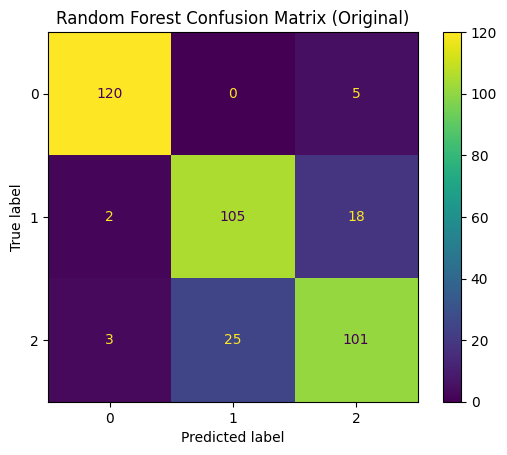

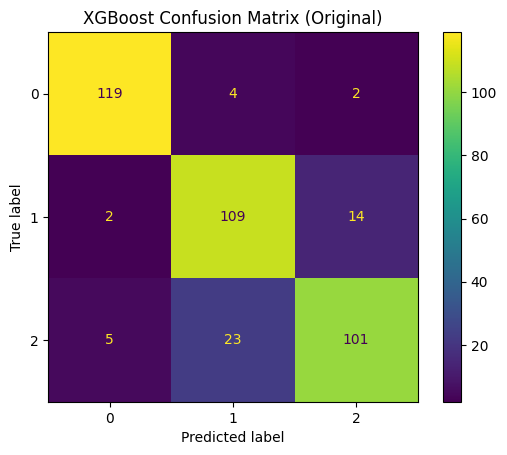

In [102]:
confision_matrix = confusion_matrix(y, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=confision_matrix)
disp.plot()
plt.title("Random Forest Confusion Matrix (Original)")
plt.show()

confision_matrix = confusion_matrix(y, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=confision_matrix)
disp.plot()
plt.title("XGBoost Confusion Matrix (Original)")
plt.show()

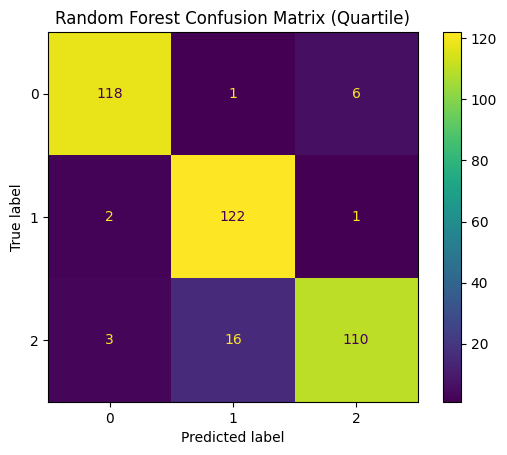

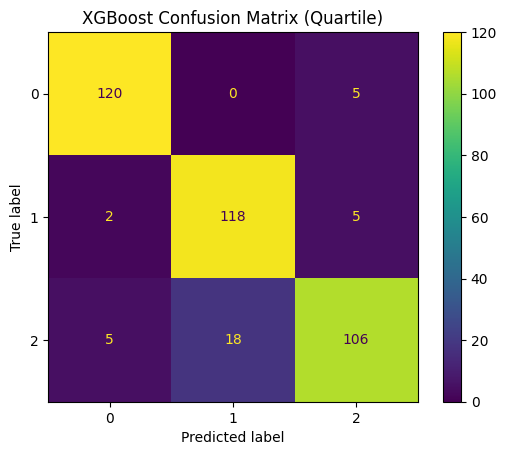

In [103]:
confision_matrix = confusion_matrix(yQ, y_rf_q)
disp = ConfusionMatrixDisplay(confusion_matrix=confision_matrix)
disp.plot()
plt.title("Random Forest Confusion Matrix (Quartile)")
plt.show()


confision_matrix = confusion_matrix(yQ, y_xgb_q)
disp = ConfusionMatrixDisplay(confusion_matrix=confision_matrix)
disp.plot()
plt.title("XGBoost Confusion Matrix (Quartile)")
plt.show()